# Importing Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from matplotlib import rcParams
# from plotly.offline import init_notebook_mode
# init_notebook_mode(connected=True)
import plotly.express as px
import warnings
import time
import datetime as dt
warnings.filterwarnings("ignore")
from typing import Optional, Tuple, List, Any
from datasets import load_dataset
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()

# Importing Train, Test and Validation datasets

In [6]:
! gdown 1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
! gdown 1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
! gdown 1dn731As0myZMyq886-XLBfoi29mYxRes
! gdown 1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
! gdown 1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
! gdown 1Az4qS0h_xHgR62O338949jrlwfMal11F

Downloading...
From: https://drive.google.com/uc?id=1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
To: /content/X_train.pkl
100% 12.9M/12.9M [00:00<00:00, 109MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
To: /content/X_val.pkl
100% 4.13M/4.13M [00:00<00:00, 91.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dn731As0myZMyq886-XLBfoi29mYxRes
To: /content/X_test.pkl
100% 4.13M/4.13M [00:00<00:00, 65.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
To: /content/y_train.pkl
100% 1.52M/1.52M [00:00<00:00, 163MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
To: /content/y_val.pkl
100% 506k/506k [00:00<00:00, 104MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Az4qS0h_xHgR62O338949jrlwfMal11F
To: /content/y_test.pkl
100% 506k/506k [00:00<00:00, 111MB/s]


In [7]:
import joblib
X_train_tfidf = joblib.load('/content/X_train.pkl')
X_test_tfidf = joblib.load('/content/X_test.pkl')
X_val_tfidf = joblib.load('/content/X_test.pkl')
y_train = joblib.load('/content/y_train.pkl')
y_test = joblib.load('/content/y_test.pkl')
y_val = joblib.load('/content/y_val.pkl')

# Dimnensionality Reduction for LightGBM model

In [8]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(
    n_components = 300,
    random_state = 42
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

In [9]:
X_train_svd = pd.DataFrame(
    X_train_svd,
    columns=[f"SVD_{i}" for i in range(X_train_svd.shape[1])]
)
X_train_svd

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.002554,-0.002672,-0.001319,-0.001313,0.000233,0.000605,-0.001338,-0.000637,0.001510,-0.000695,...,0.002892,-0.000669,-0.001820,-0.001779,0.001358,0.002301,0.002168,-0.000605,-0.001861,-0.003926
1,0.028482,-0.024638,-0.019036,-0.032353,0.022331,0.007619,-0.015155,0.014825,-0.016071,-0.014862,...,0.003521,0.014162,-0.008000,0.015863,0.038201,0.012079,0.001333,-0.002943,-0.016701,-0.021854
2,0.037887,-0.054277,-0.021020,0.062595,-0.085130,0.110696,0.017173,-0.032228,-0.017228,-0.002255,...,-0.010569,-0.005654,-0.001296,-0.004301,0.000463,0.004418,0.000768,0.006306,-0.010366,0.014936
3,0.042709,-0.059601,-0.030265,-0.037011,0.025671,0.008645,-0.037272,0.020342,-0.012219,-0.008526,...,0.030543,-0.028895,0.016906,0.002731,-0.014932,-0.005888,-0.010335,0.034966,0.001024,0.006119
4,0.047168,-0.064926,-0.036266,-0.026730,0.022420,0.001392,-0.031648,0.010774,-0.000412,0.007301,...,-0.008471,0.013249,-0.015482,-0.000101,0.014631,-0.012554,-0.007901,0.031357,0.000419,0.014238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47367,0.527493,0.359805,-0.001829,0.054736,-0.073088,-0.099908,-0.049753,0.007358,-0.126574,0.039872,...,0.000995,-0.002661,0.005125,-0.004062,0.004270,-0.005069,-0.004758,0.004089,-0.002760,0.014285
47368,0.050446,-0.074672,0.115689,0.031723,-0.046415,0.069428,0.004412,0.013389,-0.021355,0.007922,...,-0.062785,-0.035079,-0.014336,0.023950,-0.002289,0.017832,0.028960,0.040196,-0.038179,-0.019939
47369,0.030535,-0.040805,-0.017480,0.101565,0.098974,0.005378,0.013198,-0.034698,-0.024136,-0.010255,...,-0.010337,-0.003928,0.003521,0.005196,-0.009177,-0.020886,0.000148,0.006416,-0.002341,-0.002326
47370,0.067010,-0.097161,0.112342,-0.025796,0.024368,-0.000582,-0.036928,0.006709,-0.018211,-0.014595,...,0.010401,0.033345,-0.002831,-0.001965,-0.009737,0.015321,0.005938,0.003407,-0.019801,0.019168


In [10]:
X_val_svd = pd.DataFrame(
    X_val_svd,
    columns=[f"SVD_{i}" for i in range(X_val_svd.shape[1])]
)
X_val_svd

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.069213,-0.095159,0.003501,0.014114,-0.051139,0.042948,0.065068,0.033784,-0.003260,0.016010,...,-0.017573,-0.018274,-0.026092,-0.011489,0.012845,-0.034032,-0.012610,-0.008900,0.027948,-0.017076
1,0.056932,-0.075662,-0.035897,-0.033610,0.001326,-0.028906,0.033509,0.030671,-0.016408,0.002210,...,-0.018709,0.004958,0.013360,-0.021335,0.028662,0.031239,-0.022904,-0.013606,-0.013401,0.028812
2,0.052092,-0.071983,0.015072,-0.019305,0.002019,-0.029008,-0.013870,-0.059015,0.003149,-0.006806,...,-0.009081,0.008583,-0.009994,-0.006114,-0.015036,0.020595,-0.016263,0.001676,0.015461,0.004329
3,0.092855,-0.125781,0.083514,0.016704,-0.052772,0.066376,-0.013615,-0.026057,-0.014205,-0.027203,...,0.007405,0.003754,0.006617,-0.023947,0.027046,0.006523,0.029435,0.041579,-0.027417,-0.014887
4,0.066509,-0.058374,-0.039395,0.040435,-0.067546,-0.114717,-0.062191,0.015986,-0.082776,0.004630,...,0.009798,-0.024535,-0.003056,0.011755,-0.023302,-0.017544,-0.006797,0.005147,-0.022951,0.003669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15786,0.016463,-0.021420,-0.008292,-0.005963,0.001121,-0.000891,-0.009122,-0.004755,0.000988,-0.002444,...,-0.000808,-0.021515,-0.014392,-0.003853,0.005328,-0.007217,0.016758,-0.009059,0.005386,-0.002025
15787,0.034377,-0.047521,-0.006820,-0.006403,0.007714,0.000541,-0.018541,-0.050339,0.010279,-0.023536,...,-0.015126,0.015867,-0.006635,0.040601,0.020519,-0.007358,0.012779,0.018275,0.003649,-0.012052
15788,0.019810,-0.029040,-0.008910,0.004587,0.003336,-0.005944,-0.004948,-0.036956,0.014254,0.001497,...,-0.011044,0.022957,0.011466,-0.005408,0.003387,0.002031,0.010179,-0.002288,-0.007012,0.010268
15789,0.054190,-0.075180,-0.031395,0.052733,-0.074967,0.098642,0.004289,-0.039401,-0.003026,0.034531,...,-0.026042,-0.022801,-0.028095,-0.005973,-0.026975,-0.047744,-0.027153,0.017399,-0.008896,-0.001820


In [11]:
X_test_svd = pd.DataFrame(
    X_test_svd,
    columns=[f"SVD_{i}" for i in range(X_test_svd.shape[1])]
)
X_test_svd

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.069213,-0.095159,0.003501,0.014114,-0.051139,0.042948,0.065068,0.033784,-0.003260,0.016010,...,-0.017573,-0.018274,-0.026092,-0.011489,0.012845,-0.034032,-0.012610,-0.008900,0.027948,-0.017076
1,0.056932,-0.075662,-0.035897,-0.033610,0.001326,-0.028906,0.033509,0.030671,-0.016408,0.002210,...,-0.018709,0.004958,0.013360,-0.021335,0.028662,0.031239,-0.022904,-0.013606,-0.013401,0.028812
2,0.052092,-0.071983,0.015072,-0.019305,0.002019,-0.029008,-0.013870,-0.059015,0.003149,-0.006806,...,-0.009081,0.008583,-0.009994,-0.006114,-0.015036,0.020595,-0.016263,0.001676,0.015461,0.004329
3,0.092855,-0.125781,0.083514,0.016704,-0.052772,0.066376,-0.013615,-0.026057,-0.014205,-0.027203,...,0.007405,0.003754,0.006617,-0.023947,0.027046,0.006523,0.029435,0.041579,-0.027417,-0.014887
4,0.066509,-0.058374,-0.039395,0.040435,-0.067546,-0.114717,-0.062191,0.015986,-0.082776,0.004630,...,0.009798,-0.024535,-0.003056,0.011755,-0.023302,-0.017544,-0.006797,0.005147,-0.022951,0.003669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15786,0.016463,-0.021420,-0.008292,-0.005963,0.001121,-0.000891,-0.009122,-0.004755,0.000988,-0.002444,...,-0.000808,-0.021515,-0.014392,-0.003853,0.005328,-0.007217,0.016758,-0.009059,0.005386,-0.002025
15787,0.034377,-0.047521,-0.006820,-0.006403,0.007714,0.000541,-0.018541,-0.050339,0.010279,-0.023536,...,-0.015126,0.015867,-0.006635,0.040601,0.020519,-0.007358,0.012779,0.018275,0.003649,-0.012052
15788,0.019810,-0.029040,-0.008910,0.004587,0.003336,-0.005944,-0.004948,-0.036956,0.014254,0.001497,...,-0.011044,0.022957,0.011466,-0.005408,0.003387,0.002031,0.010179,-0.002288,-0.007012,0.010268
15789,0.054190,-0.075180,-0.031395,0.052733,-0.074967,0.098642,0.004289,-0.039401,-0.003026,0.034531,...,-0.026042,-0.022801,-0.028095,-0.005973,-0.026975,-0.047744,-0.027153,0.017399,-0.008896,-0.001820


# Hyperparameter tuning of individual models

## Hyperparameter tuning of Logistic regression

In [12]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


In [13]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score,roc_auc_score
RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 50
skf = StratifiedKFold(n_splits = N_SPLITS, shuffle = True, random_state = RANDOM_STATE)

In [14]:
def tune_logistic_regression(X_train_tfidf,y_train, n_trials = 30):

  def objective(trial):
    C = trial.suggest_float("C",1e-3,10.0, log=True)
    model = LogisticRegression(
        C=C,
        solver = "liblinear",
        class_weight = 'balanced',
        max_iter = 2000,
        random_state = RANDOM_STATE
    )
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict_proba(X_val_tfidf)[:,1]
    return roc_auc_score(y_val,y_pred)
  study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.TPESampler(seed=42))
  study.optimize(objective, n_trials = n_trials)
  best_params = {
      "C" : study.best_params['C'],
      "max_iter": 2000,
      "solver": "liblinear",
      "class_weight": 'balanced',
      'random_state': RANDOM_STATE
  }
  print("Best LR AUC:", study.best_value)
  print("Best LR params:", best_params)
  return best_params

lr_best_params = tune_logistic_regression(X_train_tfidf,y_train,n_trials = N_TRIALS)

[I 2026-04-13 21:53:34,992] A new study created in memory with name: no-name-a3589614-d128-41a2-8197-d9d22b1b2235
[I 2026-04-13 21:53:36,182] Trial 0 finished with value: 0.4973196975711921 and parameters: {'C': 0.03148911647956861}. Best is trial 0 with value: 0.4973196975711921.
[I 2026-04-13 21:53:39,052] Trial 1 finished with value: 0.5002175885349456 and parameters: {'C': 6.351221010640703}. Best is trial 1 with value: 0.5002175885349456.
[I 2026-04-13 21:53:40,734] Trial 2 finished with value: 0.4987485770897244 and parameters: {'C': 0.8471801418819978}. Best is trial 1 with value: 0.5002175885349456.
[I 2026-04-13 21:53:41,618] Trial 3 finished with value: 0.4980154513533975 and parameters: {'C': 0.24810409748678125}. Best is trial 1 with value: 0.5002175885349456.
[I 2026-04-13 21:53:42,374] Trial 4 finished with value: 0.4969191324828553 and parameters: {'C': 0.004207988669606638}. Best is trial 1 with value: 0.5002175885349456.
[I 2026-04-13 21:53:43,099] Trial 5 finished wit

Best LR AUC: 0.5005411471793882
Best LR params: {'C': 9.945483979496762, 'max_iter': 2000, 'solver': 'liblinear', 'class_weight': 'balanced', 'random_state': 42}


## Hyperparameter tuning of Naive Bayes classifier

In [15]:
from sklearn.naive_bayes import MultinomialNB
def tune_naive_bayes(X_train_tfidf,y_train, n_trials = 30):

  def objective(trial):
    alpha = trial.suggest_float("alpha",1e-3,10.0, log=True)
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict_proba(X_val_tfidf)[:,1]
    return roc_auc_score(y_val,y_pred)
  study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.TPESampler(seed=42))
  study.optimize(objective, n_trials = n_trials)
  best_params = {
      "alpha" : study.best_params['alpha']
  }
  print("Best NB AUC:", study.best_value)
  print("Best NB params:", best_params)
  return best_params

nb_best_params = tune_naive_bayes(X_train_tfidf,y_train,n_trials = N_TRIALS)

[I 2026-04-13 21:54:51,752] A new study created in memory with name: no-name-f3b107ad-9aef-4981-a3fa-ec4ac6eb7899
[I 2026-04-13 21:54:51,812] Trial 0 finished with value: 0.4985372466321114 and parameters: {'alpha': 0.03148911647956861}. Best is trial 0 with value: 0.4985372466321114.
[I 2026-04-13 21:54:51,863] Trial 1 finished with value: 0.4985371503539986 and parameters: {'alpha': 6.351221010640703}. Best is trial 0 with value: 0.4985372466321114.
[I 2026-04-13 21:54:51,926] Trial 2 finished with value: 0.4994151586037491 and parameters: {'alpha': 0.8471801418819978}. Best is trial 2 with value: 0.4994151586037491.
[I 2026-04-13 21:54:51,979] Trial 3 finished with value: 0.499487367188355 and parameters: {'alpha': 0.24810409748678125}. Best is trial 3 with value: 0.499487367188355.
[I 2026-04-13 21:54:52,056] Trial 4 finished with value: 0.49739898259708926 and parameters: {'alpha': 0.004207988669606638}. Best is trial 3 with value: 0.499487367188355.
[I 2026-04-13 21:54:52,107] Tr

Best NB AUC: 0.4995421173418383
Best NB params: {'alpha': 0.3832002315345676}


## Hyperaparameter tuning of LightGBM

In [16]:
from lightgbm import LGBMClassifier, early_stopping,log_evaluation
def tune_lightGBM(X_train_svd,y_train,X_val_svd,y_val, n_trials = 30):
  def objective(trial):
    max_depth = trial.suggest_int('max_depth',3,10)
    num_leaves = trial.suggest_int('num_leaves',8, min(2**max_depth,256))
    params = {
        "objective": "binary",
        "metric":"binary_logloss",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int('n_estimators',500,2000),
        "learning_rate": trial.suggest_float('learning_rate',1e-3,0.1, log=True),
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "min_child_samples": trial.suggest_int("min_child_samples",5,50),
        "subsample": trial.suggest_float("subsample", 0.6,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,1.0),
        "reg_alpha": trial.suggest_float("reg_alpha",1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda",1e-4, 10.0, log=True),
        "random_state":42,
        "n_jobs":-1,
        "verbosity":-1

    }

    model = LGBMClassifier(**params)
    model.fit(X_train_svd,
              y_train,
              eval_set = [(X_val_svd, y_val)],
              eval_metric = 'binary_logloss',
              callbacks = [
                  early_stopping(stopping_rounds = 50, verbose = False),
                  log_evaluation(period = 0)
              ]
              )
    y_pred = model.predict_proba(X_val_svd)[:,1]
    return roc_auc_score(y_val,y_pred)
  study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.TPESampler(seed=42))
  study.optimize(objective, n_trials = n_trials)
  best_params = study.best_params
  print("Best LGB AUC:", study.best_value)
  print("Best LGB params:", best_params)
  return best_params

lgb_best_params = tune_lightGBM(X_train_svd,y_train,X_val_svd,y_val,n_trials = N_TRIALS)


[I 2026-04-13 21:55:01,194] A new study created in memory with name: no-name-04073deb-77aa-4ff3-84ee-13e31a20c201
[I 2026-04-13 21:55:24,748] Trial 0 finished with value: 0.4978814402435451 and parameters: {'max_depth': 5, 'num_leaves': 31, 'n_estimators': 1598, 'learning_rate': 0.015751320499779727, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 0 with value: 0.4978814402435451.
[I 2026-04-13 21:55:40,125] Trial 1 finished with value: 0.4953812019552159 and parameters: {'max_depth': 8, 'num_leaves': 13, 'n_estimators': 1955, 'learning_rate': 0.04622589001020832, 'min_child_samples': 14, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675}. Best is trial 0 with value: 0.4978814402435451.
[I 2026-04-13 21:55:50,110] Trial 2 finished with value: 0.4918499534495325 an

Best LGB AUC: 0.5009747677531223
Best LGB params: {'max_depth': 3, 'num_leaves': 8, 'n_estimators': 1724, 'learning_rate': 0.025924756604751596, 'min_child_samples': 38, 'subsample': 0.9085081386743783, 'colsample_bytree': 0.6296178606936361, 'reg_alpha': 0.006199100007802264, 'reg_lambda': 0.00037961668958008145}


In [17]:
y_val.value_counts()

,count
label,
0,8035
1,7756


# Generate Out-of-fold predictions

In [18]:
def generate_oof_predictions(X_train_tfidf, X_train_svd,y_train, nb_params, lr_params, lgb_params):
  oof_nb = np.zeros(len(y_train))
  oof_lr = np.zeros(len(y_train))
  oof_lgb = np.zeros(len(y_train))
  for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_tfidf,y_train),1):
    print(f"Generating OOF predictions for fold {fold}")
    X_tr_tfidf,X_va_tfidf = X_train_tfidf[tr_idx], X_train_tfidf[va_idx]
    X_tr_svd,X_va_svd = X_train_svd.iloc[tr_idx], X_train_svd.iloc[va_idx]
    y_tr,y_va = y_train.iloc[tr_idx],y_train.iloc[va_idx]

    # naive bayes
    nb_model = MultinomialNB(**nb_params)
    nb_model.fit(X_tr_tfidf,y_tr)
    oof_nb[va_idx] = nb_model.predict_proba(X_va_tfidf)[:,1]

    #logistic regression
    lr_model = LogisticRegression(**lr_params)
    lr_model.fit(X_tr_tfidf,y_tr)
    oof_lr[va_idx] = lr_model.predict_proba(X_va_tfidf)[:,1]

    # LightGBM
    lgb_model = LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_tr_svd, y_tr,
        eval_set = [(X_va_svd, y_va)],
        eval_metric = "binary_logloss",
        callbacks = [
            early_stopping(stopping_rounds = 100, verbose = False)
        ]
    )
    oof_lgb[va_idx] = lgb_model.predict_proba(X_va_svd)[:,1]
  return oof_nb, oof_lr, oof_lgb




In [19]:
oof_nb, oof_lr, oof_lgb = generate_oof_predictions(
    X_train_tfidf,
    X_train_svd,
    y_train,
    nb_best_params,
    lr_best_params,
    lgb_best_params
)


Generating OOF predictions for fold 1
Generating OOF predictions for fold 2
Generating OOF predictions for fold 3
Generating OOF predictions for fold 4
Generating OOF predictions for fold 5


In [20]:
final_model = LGBMClassifier(**lgb_best_params)
final_model.fit(X_train_svd,
          y_train)

LGBMClassifier(colsample_bytree=0.6296178606936361,
               learning_rate=0.025924756604751596, max_depth=3,
               min_child_samples=38, n_estimators=1724, num_leaves=8,
               reg_alpha=0.006199100007802264,
               reg_lambda=0.00037961668958008145, subsample=0.9085081386743783)

In [21]:
y_pred = final_model.predict(X_test_svd)
y_pred

array([1, 0, 1, ..., 1, 1, 0])

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuarcy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("f1 score:",f1_score(y_test, y_pred))

Accuarcy: 0.7529605471471091
Precision: 0.78573546856465
Recall: 0.6833010960670535
f1 score: 0.7309469618594385


# Train Meta-Learner

In [23]:
def train_meta_learner(oof_nb, oof_lr, oof_lgb, y_train):
  meta_X = np.column_stack([oof_nb, oof_lr, oof_lgb])
  meta_model = LogisticRegression(
      C = 1.0,
      max_iter = 2000,
      solver  = 'lbfgs',
      random_state = RANDOM_STATE,


  )
  meta_model.fit(meta_X, y_train)
  stacked_oof = meta_model.predict_proba(meta_X)[:,1]
  print("OOF AUC - Naive Bayes :", roc_auc_score(y_train, oof_nb))
  print("OOF AUC - Logistic Reg:", roc_auc_score(y_train, oof_lr))
  print("OOF AUC - LightGBM    :", roc_auc_score(y_train, oof_lgb))
  print("OOF AUC - Stacking    :", roc_auc_score(y_train, stacked_oof))
  return meta_model


meta_model = train_meta_learner(oof_nb, oof_lr, oof_lgb, y_train)


OOF AUC - Naive Bayes : 0.8379077396274994
OOF AUC - Logistic Reg: 0.8926353696058975
OOF AUC - LightGBM    : 0.83351183940747
OOF AUC - Stacking    : 0.8976076305053122


# Train base models on full data

In [24]:
def train_final_base_models(X_train_tfidf, X_train_svd, y_train, nb_params, lr_params, lgb_params):
  final_nb = MultinomialNB(**nb_params)
  final_nb.fit(X_train_tfidf, y_train)
  final_lr = LogisticRegression(**lr_params)
  final_lr.fit(X_train_tfidf, y_train)
  final_lgb = LGBMClassifier(**lgb_params)
  final_lgb.fit(X_train_svd, y_train)
  return final_nb, final_lr, final_lgb
final_nb, final_lr, final_lgb = train_final_base_models(X_train_tfidf,
                                                        X_train_svd,
                                                        y_train,
                                                        nb_best_params,
                                                        lr_best_params,
                                                        lgb_best_params)



# Making predictions using stacking classifier

In [25]:
def stacking_predict(X_test_tfidf, X_test_svd, final_nb, final_lr, final_lgb, meta_model):
  p_nb = final_nb.predict_proba(X_test_tfidf)[:,1]
  p_lr = final_lr.predict_proba(X_test_tfidf)[:,1]
  p_lgb = final_lgb.predict_proba(X_test_svd)[:,1]
  meta_X_test = np.column_stack([p_nb, p_lr, p_lgb])
  stacking_proba = meta_model.predict_proba(meta_X_test)[:,1]
  stacking_pred = (stacking_proba >= 0.5).astype(int)
  return stacking_pred, stacking_proba

stacking_pred, stacking_proba = stacking_predict(X_test_tfidf,
                                                 X_test_svd,
                                                 final_nb,
                                                 final_lr,
                                                 final_lgb,
                                                 meta_model)

stacking_pred


array([1, 0, 0, ..., 1, 1, 1])

# Evaluation

In [26]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuarcy of Stacking Classifier :",accuracy_score(y_test, stacking_pred))
print("Precision of Stacking Classifier:",precision_score(y_test, stacking_pred))
print("Recall of Stacking Classifier:",recall_score(y_test, stacking_pred))
print("f1 score: of Stacking Classifier:",f1_score(y_test, stacking_pred))
print("ROC-AUC score of Stacking Classifier:", roc_auc_score(y_test,stacking_pred))

Accuarcy of Stacking Classifier : 0.8228737888670762
Precision of Stacking Classifier: 0.8352718420340817
Recall of Stacking Classifier: 0.7963894261766602
f1 score: of Stacking Classifier: 0.8153673509802627
ROC-AUC score of Stacking Classifier: 0.8224107409628946


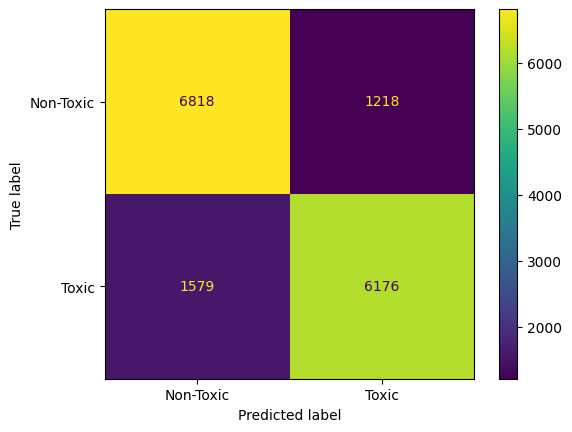

In [27]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.reset_orig()
labels = ["Non-Toxic", "Toxic"]
cm=confusion_matrix(y_test,stacking_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
disp.plot()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,stacking_pred))


              precision    recall  f1-score   support

           0       0.81      0.85      0.83      8036
           1       0.84      0.80      0.82      7755

    accuracy                           0.82     15791
   macro avg       0.82      0.82      0.82     15791
weighted avg       0.82      0.82      0.82     15791



In [29]:
import pickle
import os
save_path = "/content/"
y_prob_stack = stacking_proba
with open(save_path + "y_prob_stack.pkl", "wb") as f:
    pickle.dump(y_prob_stack, f)

## Assessment

### Stacking Classifier


**Why this model was chosen**
- Stacking was used to combine the strengths of multiple models:
  - Naive Bayes → probabilistic word patterns
  - Logistic Regression → linear relationships
  - LightGBM → non-linear interactions
  - This improves overall performance by leveraging complementary behaviors.

**Model assumptions**
- Assumes base models capture different patterns
- Meta-model (Logistic Regression) assumes a linear combination of base predictions  

**Hyperparameter tuning**
- Each base model was tuned individually using Optuna
- Used out-of-fold (OOF) predictions for training the meta-model
- Meta-model: Logistic Regression with default/regularized parameters  

**Challenges & solutions**

$$
\begin{array}{|l|l|}
\hline
\textbf{Challenge} & \textbf{Solution} \\
\hline
\text{Data leakage risk} & \text{Used OOF predictions with StratifiedKFold} \\
\hline
\text{Different preprocessing requirements} &
\begin{array}{l}
\text{TF-IDF for Naive Bayes & Logistic Regression} \\
\text{TF-IDF + SVD for LightGBM}
\end{array} \\
\hline
\end{array}
$$

# Before and after transformation snapshot

## Before transformation

In [30]:
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw

Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 116MB/s] 


In [31]:
import pandas as pd
df_raw = pd.read_csv('/content/combined_model_dataset.csv')
df_raw[['text', 'label']].head()

,text,label
0,"this is politicians' strategy\n\n""Action throu...",0
1,He has underlings to do tjat for him,0
2,"Judge on separation of immigrant families: ""if...",0
3,To the republican nra(Nazi's Razing America)th...,0
4,Somebody musta complained.,0


In [44]:
df_raw = pd.read_csv('/content/combined_model_dataset.csv')
print('BEFORE: Raw Text:')
print('\nShape:', df_raw.shape)
print('Dtype:', df_raw['text'].dtype)

BEFORE: Raw Text:

Shape: (78954, 2)
Dtype: object


The stacking classifier uses a two-stage transformation. First, base models (Logistic Regression, Naive Bayes, and LightGBM) generate predictions using TF-IDF and SVD features. Then, these predictions are combined as new features (meta-features), where each column represents the probability output of a base model. These meta-features are used to train a Logistic Regression meta-model for final prediction.

### TF-IDF features for Naive Bayes and Logistic Regression models

In [42]:
import scipy.sparse

X_train_dense = X_train_tfidf.toarray() if scipy.sparse.issparse(X_train_tfidf) else np.array(X_train_tfidf)

# Find rows and columns that contain at least one non-zero value for a meaningful snapshot
nonzero_rows = np.where(X_train_dense.any(axis=1))[0][:5]
nonzero_cols = np.where(X_train_dense[nonzero_rows].any(axis=0))[0][:10]

df_after = pd.DataFrame(
    X_train_dense[np.ix_(nonzero_rows, nonzero_cols)],
    columns=[f'Feature_{c}' for c in nonzero_cols],
    index=[f'Row_{r}' for r in nonzero_rows]
)
df_after

,Feature_402,Feature_406,Feature_521,Feature_805,Feature_856,Feature_863,Feature_1901,Feature_2294,Feature_2515,Feature_2614
Row_0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Row_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Row_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Row_3,0.000000,0.000000,0.000000,0.163083,0.214454,0.203032,0.000000,0.318836,0.000000,0.000000
Row_4,0.072057,0.106535,0.481444,0.000000,0.000000,0.000000,0.105086,0.000000,0.073881,0.108207


In [45]:
print('AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):')
print(df_after.to_string())
print(f'Full shape: {X_train_dense.shape}')
print(f'Dtype: {X_train_dense.dtype}')
print(f'Sparsity: {100 * (X_train_dense == 0).sum() / X_train_dense.size:.1f}% zeros (expected for TF-IDF)')

AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):
       Feature_402  Feature_406  Feature_521  Feature_805  Feature_856  Feature_863  Feature_1901  Feature_2294  Feature_2515  Feature_2614
Row_0     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_1     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_2     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_3     0.000000     0.000000     0.000000     0.163083     0.214454     0.203032      0.000000      0.318836      0.000000      0.000000
Row_4     0.072057     0.106535     0.481444     0.000000     0.000000     0.000000      0.105086      0.000000      0.073881      0.108207
Full shape: (47372, 50000)
Dtype: float64
Sparsity: 100.0% zeros (expected for TF-IDF)

### SVD features for LightGBM model

In [33]:
X_train_svd

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.002554,-0.002672,-0.001319,-0.001313,0.000233,0.000605,-0.001338,-0.000637,0.001510,-0.000695,...,0.002892,-0.000669,-0.001820,-0.001779,0.001358,0.002301,0.002168,-0.000605,-0.001861,-0.003926
1,0.028482,-0.024638,-0.019036,-0.032353,0.022331,0.007619,-0.015155,0.014825,-0.016071,-0.014862,...,0.003521,0.014162,-0.008000,0.015863,0.038201,0.012079,0.001333,-0.002943,-0.016701,-0.021854
2,0.037887,-0.054277,-0.021020,0.062595,-0.085130,0.110696,0.017173,-0.032228,-0.017228,-0.002255,...,-0.010569,-0.005654,-0.001296,-0.004301,0.000463,0.004418,0.000768,0.006306,-0.010366,0.014936
3,0.042709,-0.059601,-0.030265,-0.037011,0.025671,0.008645,-0.037272,0.020342,-0.012219,-0.008526,...,0.030543,-0.028895,0.016906,0.002731,-0.014932,-0.005888,-0.010335,0.034966,0.001024,0.006119
4,0.047168,-0.064926,-0.036266,-0.026730,0.022420,0.001392,-0.031648,0.010774,-0.000412,0.007301,...,-0.008471,0.013249,-0.015482,-0.000101,0.014631,-0.012554,-0.007901,0.031357,0.000419,0.014238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47367,0.527493,0.359805,-0.001829,0.054736,-0.073088,-0.099908,-0.049753,0.007358,-0.126574,0.039872,...,0.000995,-0.002661,0.005125,-0.004062,0.004270,-0.005069,-0.004758,0.004089,-0.002760,0.014285
47368,0.050446,-0.074672,0.115689,0.031723,-0.046415,0.069428,0.004412,0.013389,-0.021355,0.007922,...,-0.062785,-0.035079,-0.014336,0.023950,-0.002289,0.017832,0.028960,0.040196,-0.038179,-0.019939
47369,0.030535,-0.040805,-0.017480,0.101565,0.098974,0.005378,0.013198,-0.034698,-0.024136,-0.010255,...,-0.010337,-0.003928,0.003521,0.005196,-0.009177,-0.020886,0.000148,0.006416,-0.002341,-0.002326
47370,0.067010,-0.097161,0.112342,-0.025796,0.024368,-0.000582,-0.036928,0.006709,-0.018211,-0.014595,...,0.010401,0.033345,-0.002831,-0.001965,-0.009737,0.015321,0.005938,0.003407,-0.019801,0.019168


In [48]:
print('AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):')
print(f'Full shape: {X_train_svd.shape}')
print(f'Dtype: {X_train_svd['SVD_0'].dtype}')

AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):
Full shape: (47372, 300)
Dtype: float64


### Out-of-fold stacked predictions for meta learner

In [39]:
meta_X = np.column_stack([oof_nb, oof_lr, oof_lgb])
meta_X

array([[0.42268161, 0.12220011, 0.20900086],
       [0.41131291, 0.51538955, 0.24118471],
       [0.46155362, 0.31270461, 0.37525366],
       ...,
       [0.51448276, 0.71406233, 0.95357887],
       [0.66035475, 0.84905276, 0.65174627],
       [0.25055414, 0.06984457, 0.25386725]])

## Transformation summary

In [35]:
import pandas as pd

data = {
    "Stage": ["BEFORE", "STEP", "STEP", "AFTER"],
    "Description": [
        "Raw Text",
        "TF-IDF (for NB + LR base models)",
        "TF-IDF + SVD (for LightGBM base model)",
        "OOF base model predictions (meta-model input)"
    ],
    "Format": [
        "String",
        "Sparse float64 matrix",
        "Dense float64 matrix",
        "Dense float64 matrix"
    ],
    "Shape": [
        "(N,)",
        "(N, 50,000)",
        "(N, 300)",
        "(N, 3)"
    ]
}

summary = pd.DataFrame(data)

summary

,Stage,Description,Format,Shape
0,BEFORE,Raw Text,String,"(N,)"
1,STEP,TF-IDF (for NB + LR base models),Sparse float64 matrix,"(N, 50,000)"
2,STEP,TF-IDF + SVD (for LightGBM base model),Dense float64 matrix,"(N, 300)"
3,AFTER,OOF base model predictions (meta-model input),Dense float64 matrix,"(N, 3)"
